### Methodology: historical field-survey comparison

Historical radar and lagoon bathymetry data were obtained from the Australian Antarctic Data Centre (Allison and Thost, 2010) and mapped in WGS84 / UTM zone 43S. Brown Glacier radar profiles comprised 35 survey locations at BG35 (2000), six at BG20 and eight at BG25 (2004). Missing or zero returns were excluded, and the source-labelled W and E returns were retained separately.

Modelled ice thickness, bed elevation and DEM surface elevation were sampled at the survey locations from the common 50 m grid. Field bed-elevation proxies were calculated by subtracting workbook radar-derived thickness estimates from survey surface elevations. Mean bias (model minus field estimate) and RMSE were calculated by profile and return type. Unique model cells were counted because nearby observations could sample the same cell. Supplied thickness uncertainty was included for context; differences in observation dates and radar interpretation mean this constitutes a historical consistency check.

The 2004 bathymetry comprised 211 Brown Lagoon soundings and 16 available Stephenson Lagoon soundings. Depths were expressed positively below the water surface and mapped as point observations alongside historical glacier outlines.

Dataset citation: Allison and Thost (2010), DOI: 10.4225/15/574BBEA0D74B7

In [2]:
# %pip install openpyxl

In [3]:
## Locate the historical field data ##

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

import rasterio
from rasterio.transform import rowcol


project_dir = Path.cwd()
field_input_dir = project_dir / "Input_Data"

field_candidates = sorted({
    path.parent.parent
    for path in field_input_dir.rglob("Copy of stephenson_lagoon.csv")
    if (path.parent / "Copy of brown_lagoon.csv").is_file()
    and (path.parent.parent / "ASAC_2363.xml").is_file()})

if len(field_candidates) != 1:
    raise ValueError(
        "Expected one ASAC2363 folder. "
        f"Found {len(field_candidates)}: {field_candidates}")

field_dir = field_candidates[0]

print(f"Field data: {field_dir.relative_to(project_dir)}")

Field data: Input_Data\ASAC2363_Brown_Stephenson_Field_Data


In [4]:
## Prepare the 2004 lagoon soundings ##

bathy_tables = []

for name in ("Brown", "Stephenson"):
    source_path = (
        field_dir / "Lagoon_bathymetry"
        / f"Copy of {name.lower()}_lagoon.csv")

    data = pd.read_csv(source_path, encoding = "utf-8-sig")
    numeric_columns = ["E", "N", "depth"]

    data[numeric_columns] = data[numeric_columns].apply(
        pd.to_numeric, errors = "raise")

    if (
        not np.isfinite(data[numeric_columns].to_numpy()).all()
        or (data["depth"] >= 0).any()):
        raise ValueError(
            f"Invalid coordinates or depth signs in {source_path.name}.")

    # Retain the original waypoint IDs where supplied.
    data["WP"] = data.get(
        "WP", pd.Series(
            pd.NA, index = data.index, dtype = "Int64")).astype("Int64")

    data["name_1"] = name
    data["survey_year"] = 2004
    data["depth_m"] = -data["depth"]
    data["point_id"] = [
        f"{name}_2004_{number:03d}"
        for number in range(1, len(data) + 1)]

    data["source_csv"] = source_path.name
    data["coverage_note"] = (
        "Partial table; see original survey map"
        if name == "Stephenson" else "Available survey soundings")

    bathy_tables.append(data)

bathy_table = pd.concat(bathy_tables, ignore_index = True)

lagoon_soundings = gpd.GeoDataFrame(
    bathy_table,
    geometry = gpd.points_from_xy(bathy_table["E"], bathy_table["N"]),
    crs = "EPSG:32743")

field_output_dir = (
    project_dir / "Output_Data" / "processed"
    / "geomorphology" / "field_surveys")
field_output_dir.mkdir(parents = True, exist_ok = True)

lagoon_soundings.to_file(
    field_output_dir / "Heard_lagoon_soundings_2004.gpkg",
    layer = "lagoon_soundings_2004", driver = "GPKG", index = False)

map_data_dir = (
    project_dir / "Output_Data" / "processed" / "interactive_map_data")
map_data_dir.mkdir(parents = True, exist_ok = True)

lagoon_soundings.to_crs("EPSG:4326").to_file(
    map_data_dir / "lagoon_soundings_2004.geojson",
    driver = "GeoJSON", index = False)

bathy_summary = lagoon_soundings.groupby("name_1").agg(
    soundings = ("depth_m", "size"),
    deepest_sounding_m = ("depth_m", "max"))

display(bathy_summary)

,soundings,deepest_sounding_m
name_1,,
Brown,211,56.0
Stephenson,16,107.0


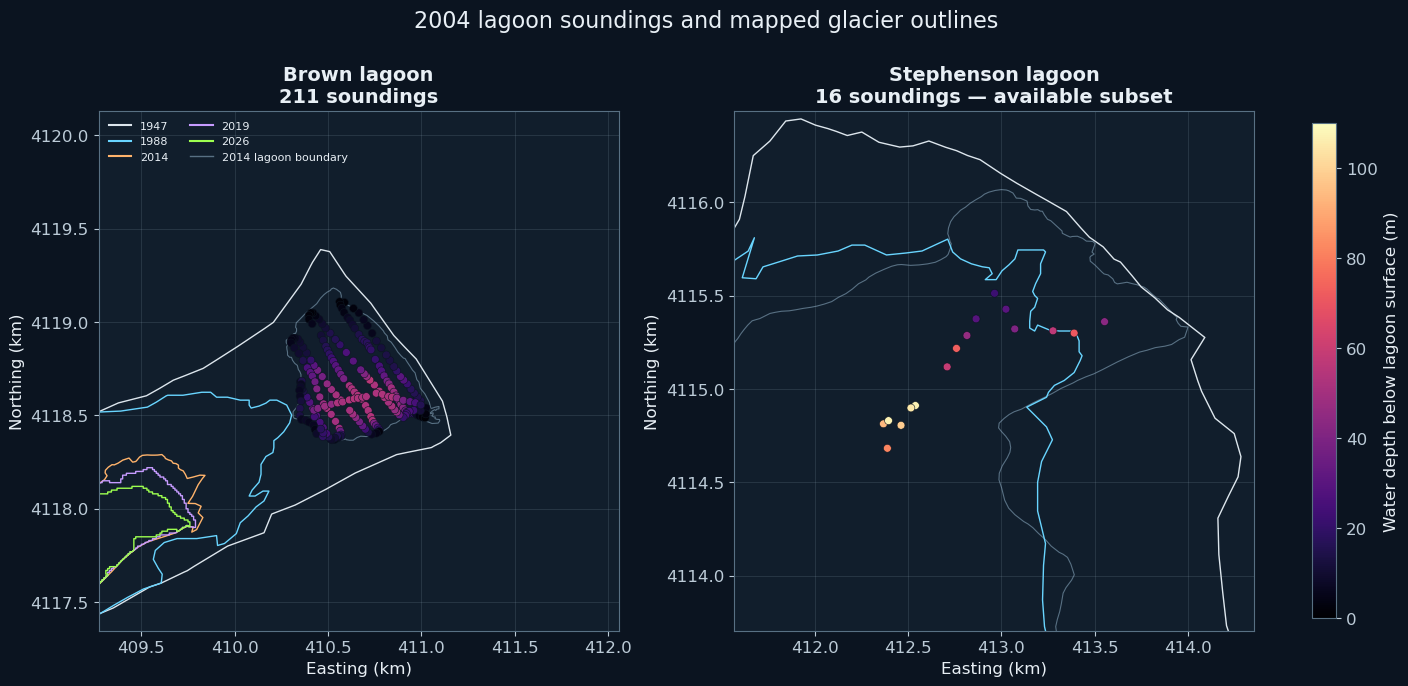

In [5]:
## Compare lagoon soundings and mapped ice margins ##

processed_dir = project_dir / "Output_Data" / "processed"

outline_path = (
    processed_dir / "interactive_map_data" / "glacier_inventories.geojson")

survey_outlines = gpd.read_file(outline_path).to_crs(lagoon_soundings.crs)
survey_outlines["year"] = pd.to_numeric(
    survey_outlines["year"], errors = "raise").astype(int)

lagoon_polygons = gpd.read_file(
    field_input_dir / "heard_island_shp"
    / "UpdatedHI_Lagoons2014.shp").to_crs(lagoon_soundings.crs)

style_path = processed_dir / "book_figure_style.json"
survey_plot_style = (
    json.loads(style_path.read_text()) if style_path.exists() else {})

year_colours = {
    1947: "#DDE6ED",
    1988: "#69D5FF",
    2014: "#FFB36B",
    2019: "#C69BFF",
    2026: "#9DFF50"}

survey_bounds = [
    lagoon_soundings.loc[
        lagoon_soundings["name_1"].eq(name)].total_bounds
    for name in ("Brown", "Stephenson")]

map_span = max(
    max(x2 - x1, y2 - y1)
    for x1, y1, x2, y2 in survey_bounds) + 1600

depth_limit = float(
    np.ceil(lagoon_soundings["depth_m"].max() / 10) * 10)

legend_handles = [
    Line2D([0], [0], color = colour, lw = 1.5, label = str(year))
    for year, colour in year_colours.items()]

legend_handles.append(
    Line2D(
        [0], [0], color = "#587083", lw = 1,
        label = "2014 lagoon boundary"))

with plt.style.context("dark_background"), plt.rc_context(survey_plot_style):
    lagoon_fig, lagoon_axes = plt.subplots(
        1, 2, figsize = (14, 7), layout = "constrained")

    for ax, name, bounds in zip(
        lagoon_axes, ("Brown", "Stephenson"), survey_bounds):

        points = lagoon_soundings.loc[
            lagoon_soundings["name_1"].eq(name)]

        ice = survey_outlines.loc[
            survey_outlines["name_1"].astype("string")
            .str.strip().str.casefold().eq(name.lower())]

        lagoon_polygons.boundary.plot(
            ax = ax, color = "#587083", linewidth = 0.8, zorder = 1)

        for year, colour in year_colours.items():
            outline = ice.loc[ice["year"].eq(year)]

            if not outline.empty:
                outline.boundary.plot(
                    ax = ax, color = colour, linewidth = 1, zorder = 2)

        depth_artist = ax.scatter(
            points["E"], points["N"], c = points["depth_m"],
            cmap = "magma", vmin = 0, vmax = depth_limit,
            s = 32, edgecolors = "#0B1420",
            linewidths = 0.4, zorder = 3)

        x1, y1, x2, y2 = bounds
        centre_x, centre_y = (x1 + x2) / 2, (y1 + y2) / 2

        qualifier = " — available subset" if name == "Stephenson" else ""

        ax.set(
            title = f"{name} lagoon\n{len(points)} soundings{qualifier}",
            xlim = (centre_x - map_span / 2, centre_x + map_span / 2),
            ylim = (centre_y - map_span / 2, centre_y + map_span / 2),
            xlabel = "Easting (km)", ylabel = "Northing (km)")

        ax.set_aspect("equal")
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda value, _: f"{value / 1000:.1f}"))
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda value, _: f"{value / 1000:.1f}"))
        ax.grid(alpha = 0.15)

    lagoon_axes[0].legend(
        handles = legend_handles, loc = "upper left",
        ncol = 2, fontsize = 8)

    lagoon_fig.colorbar(
        depth_artist, ax = lagoon_axes.tolist(),
        label = "Water depth below lagoon surface (m)", shrink = 0.75)

    lagoon_fig.suptitle(
        "2004 lagoon soundings and mapped glacier outlines", fontsize = 16)

    survey_figure_dir = project_dir / "Figures"
    survey_figure_dir.mkdir(parents = True, exist_ok = True)

    for extension in ("png", "svg"):
        lagoon_fig.savefig(
            survey_figure_dir / f"Brown_Stephenson_lagoon_soundings.{extension}",
            dpi = 300, bbox_inches = "tight")

    plt.show()

In [6]:
## Prepare the Brown radar survey locations ##

radar_depth_columns = ["depth_t1_m", "depth_W_m", "depth_E_m"]
radar_tables = []

profile_sources = [
    ("BG35", 2000, "BG35_2000.xlsx", "bg35"),
    ("BG20", 2004, "RES.xlsx", "BG20prof"),
    ("BG25", 2004, "RES.xlsx", "BG25prof")]

for profile, year, filename, sheet in profile_sources:
    raw = pd.read_excel(
        field_dir / "RES" / filename, sheet_name = sheet, header = 1)
    raw.columns = raw.columns.str.strip()

    if profile == "BG35":
        columns = {
            "mid E": "E",
            "mid N": "N",
            "mid Z": "surface_field_m",
            "depth": "depth_t1_m"}
    else:
        columns = {
            "UTM East": "E",
            "UTM North": "N",
            "Elevation": "surface_field_m",
            "depth W": "depth_W_m",
            "depth E": "depth_E_m"}

    data = raw[list(columns)].rename(columns = columns)
    data = data.apply(pd.to_numeric, errors = "coerce")
    data = data.replace([np.inf, -np.inf], np.nan)

    # Zero depth denotes a missing return in these workbooks.
    for column in radar_depth_columns:
        if column not in data:
            data[column] = np.nan

        data[column] = data[column].where(data[column] > 0)

    valid = (
        data[["E", "N", "surface_field_m"]].notna().all(axis = 1)
        & data["E"].gt(0)
        & data["N"].gt(0)
        & data[radar_depth_columns].notna().any(axis = 1))

    data = data.loc[valid].copy()

    # Retain workbook row numbers for tracing each observation.
    data["source_excel_row"] = data.index + 3
    data["profile"] = profile
    data["survey_year"] = year
    data["name_1"] = "Brown"
    data["source_file"] = filename
    data["source_sheet"] = sheet
    data["point_id"] = [
        f"{profile}_{year}_row{row}"
        for row in data["source_excel_row"]]

    data["distance_m"] = np.r_[
        0, np.hypot(np.diff(data["E"]), np.diff(data["N"]))].cumsum()

    radar_tables.append(data)

radar_table = pd.concat(radar_tables, ignore_index = True)

radar_points = gpd.GeoDataFrame(
    radar_table,
    geometry = gpd.points_from_xy(radar_table["E"], radar_table["N"]),
    crs = "EPSG:32743")

display(
    radar_points.groupby(["profile", "survey_year"]).size()
    .rename("survey_locations").to_frame())

,,survey_locations
profile,survey_year,
BG20,2004,6
BG25,2004,8
BG35,2000,35


In [7]:
## Sample the model at radar survey locations ##

def sample_radar_raster(path, points):
    values = np.full(len(points), np.nan)
    cells = pd.Series(pd.NA, index = points.index, dtype = "string")

    with rasterio.open(path) as source:
        projected = points.to_crs(source.crs)
        coordinates = np.column_stack((
            projected.geometry.x.to_numpy(),
            projected.geometry.y.to_numpy()))

        rows, cols = rowcol(
            source.transform, coordinates[:, 0], coordinates[:, 1])
        rows, cols = np.asarray(rows), np.asarray(cols)

        inside = (
            (rows >= 0) & (rows < source.height)
            & (cols >= 0) & (cols < source.width))

        if inside.any():
            samples = np.ma.vstack(list(source.sample(
                coordinates[inside], indexes = 1, masked = True)))

            values[inside] = (
                samples.astype("float64").filled(np.nan)[:, 0]
                * source.scales[0] + source.offsets[0])

            cells.loc[inside] = [
                f"{row}:{col}"
                for row, col in zip(rows[inside], cols[inside])]

    return values, cells

radar_model_dir = (
    project_dir / "Output_Data" / "processed" / "geomorphology")

radar_model_files = {
    "surface": "Heard_surface_DEM_2002_50m.tif",
    "thickness": "Heard_Millan_thickness_land_50m.tif",
    "bed": "Heard_bed_estimate_candidate_50m.tif"}

for label, filename in radar_model_files.items():
    values, cells = sample_radar_raster(
        radar_model_dir / filename, radar_points)

    radar_points[f"model_{label}_m"] = values
    radar_points[f"model_cell_{label}"] = cells

radar_points["model_thickness_m"] = radar_points[
    "model_thickness_m"].where(radar_points["model_thickness_m"] > 0)

radar_points.to_file(
    field_output_dir / "Brown_radar_model_comparison.gpkg",
    layer = "radar_model_comparison", driver = "GPKG", index = False)

In [8]:
## Summarise historical radar and model differences ##

radar_attributes = radar_points.drop(columns = "geometry")

radar_comparison = radar_attributes.melt(
    id_vars = [
        column for column in radar_attributes.columns
        if column not in radar_depth_columns],
    value_vars = radar_depth_columns,
    var_name = "return",
    value_name = "field_depth_proxy_m")

radar_comparison = radar_comparison.dropna(
    subset = ["field_depth_proxy_m"]).copy()

radar_comparison["return"] = radar_comparison["return"].map({
    "depth_t1_m": "t1",
    "depth_W_m": "W",
    "depth_E_m": "E"})

radar_comparison["field_bed_proxy_m"] = (
    radar_comparison["surface_field_m"]
    - radar_comparison["field_depth_proxy_m"])

# Positive differences mean a thicker or higher model estimate.
radar_comparison["H_delta_m"] = (
    radar_comparison["model_thickness_m"]
    - radar_comparison["field_depth_proxy_m"])

radar_comparison["bed_delta_m"] = (
    radar_comparison["model_bed_m"]
    - radar_comparison["field_bed_proxy_m"])

radar_comparison["surface_delta_m"] = (
    radar_comparison["model_surface_m"]
    - radar_comparison["surface_field_m"])

radar_metric_records = []

for (profile, year, echo), group in radar_comparison.groupby(
    ["profile", "survey_year", "return"], sort = False):

    paired = group.loc[
        group[[
            "model_surface_m", "model_thickness_m", "model_bed_m"]]
        .notna().all(axis = 1)]

    radar_metric_records.append({
        "profile": profile,
        "survey_year": year,
        "return": echo,
        "available_returns": len(group),
        "compared": len(paired),
        "model_cells": paired["model_cell_thickness"].nunique(),
        "H_bias_m": paired["H_delta_m"].mean(),
        "H_RMSE_m": np.sqrt(paired["H_delta_m"].pow(2).mean()),
        "bed_bias_m": paired["bed_delta_m"].mean(),
        "bed_RMSE_m": np.sqrt(paired["bed_delta_m"].pow(2).mean()),
        "surface_bias_m": paired["surface_delta_m"].mean()})

radar_metrics = pd.DataFrame(radar_metric_records).sort_values(
    ["survey_year", "profile", "return"])

radar_comparison.to_csv(
    field_output_dir / "Brown_radar_model_return_comparisons.csv",
    index = False)

radar_metrics.to_csv(
    field_output_dir / "Brown_radar_model_metrics.csv", index = False)

display(radar_metrics.round(2))

,profile,survey_year,return,available_returns,compared,model_cells,H_bias_m,H_RMSE_m,bed_bias_m,bed_RMSE_m,surface_bias_m
0,BG35,2000,t1,35,35,21,62.85,88.11,-59.87,83.04,2.98
3,BG20,2004,E,6,6,6,95.16,97.25,-87.40,88.40,7.75
1,BG20,2004,W,5,5,5,86.43,86.65,-82.17,82.56,4.26
4,BG25,2004,E,8,8,8,87.21,91.78,-81.78,91.07,5.43
2,BG25,2004,W,7,7,7,88.56,93.87,-78.30,87.89,10.26


In [9]:
## Check model alignment and sample thickness error ##

radar_error_filename = "Heard_Millan_thickness_error_land_50m.tif"
reference_grid = None

for filename in [
    *radar_model_files.values(), radar_error_filename]:

    with rasterio.open(radar_model_dir / filename) as source:
        grid = (
            source.crs, source.transform, source.width, source.height)

        if reference_grid is None:
            reference_grid = grid
        elif grid != reference_grid:
            raise ValueError(f"Model grid differs: {filename}")

error_values, _ = sample_radar_raster(
    radar_model_dir / radar_error_filename, radar_points)

radar_points["model_thickness_error_m"] = np.where(
    error_values >= 0, error_values, np.nan)

# Check the relationship between the three sampled model layers.
subtraction_difference = (
    radar_comparison["bed_delta_m"]
    - (
        radar_comparison["surface_delta_m"]
        - radar_comparison["H_delta_m"]))

print("All four model raster grids match.")
print(
    "Maximum bed subtraction mismatch: "
    f"{subtraction_difference.abs().max():.6f} m")

display(
    radar_points.groupby("profile").agg(
        survey_locations = ("point_id", "size"),
        model_cells = ("model_cell_thickness", "nunique"),
        locations_with_error = ("model_thickness_error_m", "count"),
        mean_supplied_error_m = ("model_thickness_error_m", "mean"))
    .round(2))

radar_points.to_file(
    field_output_dir / "Brown_radar_model_comparison.gpkg",
    layer = "radar_model_comparison", driver = "GPKG", index = False)

All four model raster grids match.
Maximum bed subtraction mismatch: 0.000031 m


,survey_locations,model_cells,locations_with_error,mean_supplied_error_m
profile,,,,
BG20,6,6,6,51.50
BG25,8,8,8,50.38
BG35,35,21,35,50.11


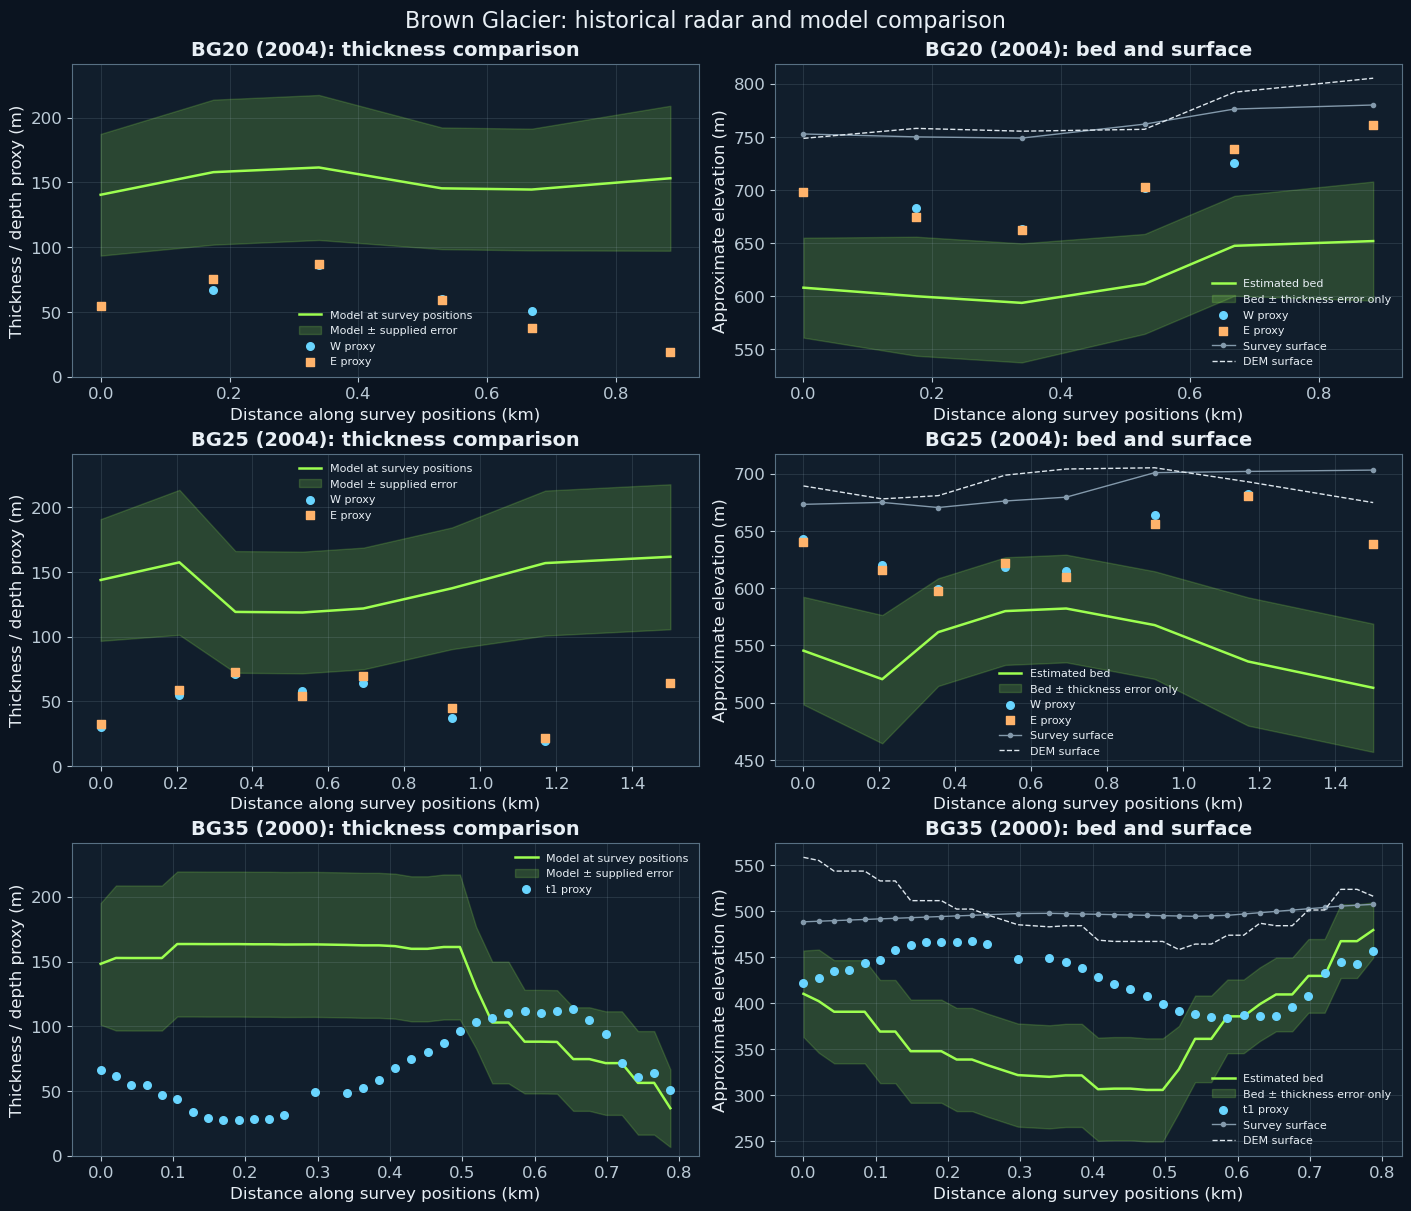

In [10]:
## Compare radar proxies and modelled cross-sections ##

profile_order = [
    ("BG20", 2004),
    ("BG25", 2004),
    ("BG35", 2000)]

return_styles = {
    "depth_t1_m": ("#69D5FF", "o", "t1 proxy"),
    "depth_W_m": ("#69D5FF", "o", "W proxy"),
    "depth_E_m": ("#FFB36B", "s", "E proxy")}

model_colour = "#9DFF50"

thickness_upper = (
    radar_points["model_thickness_m"]
    + radar_points["model_thickness_error_m"].fillna(0))

thickness_limit = max(
    float(thickness_upper.max()),
    float(radar_points[radar_depth_columns].max().max())) * 1.1

with plt.style.context("dark_background"), plt.rc_context(survey_plot_style):
    radar_fig, radar_axes = plt.subplots(
        3, 2, figsize = (14, 12),
        sharex = "row", layout = "constrained")

    for row, (profile, year) in enumerate(profile_order):
        points = radar_points.loc[
            radar_points["profile"].eq(profile)
            & radar_points["survey_year"].eq(year)
        ].sort_values("distance_m")

        distance = points["distance_m"].to_numpy() / 1000
        model_H = points["model_thickness_m"].to_numpy()
        model_bed = points["model_bed_m"].to_numpy()
        error = points["model_thickness_error_m"].to_numpy()
        field_surface = points["surface_field_m"].to_numpy()

        ax_H, ax_bed = radar_axes[row]

        ax_H.plot(
            distance, model_H, color = model_colour,
            linewidth = 1.8, label = "Model at survey positions")

        ax_bed.plot(
            distance, model_bed, color = model_colour,
            linewidth = 1.8, label = "Estimated bed")

        if np.isfinite(error).any():
            ax_H.fill_between(
                distance, model_H - error, model_H + error,
                color = model_colour, alpha = 0.18,
                label = "Model ± supplied error")

            ax_bed.fill_between(
                distance, model_bed - error, model_bed + error,
                color = model_colour, alpha = 0.18,
                label = "Bed ± thickness error only")

        for column, (colour, marker, label) in return_styles.items():
            depth = points[column].to_numpy()

            if not np.isfinite(depth).any():
                continue

            ax_H.scatter(
                distance, depth, color = colour,
                marker = marker, s = 30, zorder = 3, label = label)

            ax_bed.scatter(
                distance, field_surface - depth,
                color = colour, marker = marker,
                s = 30, zorder = 3, label = label)

        ax_bed.plot(
            distance, field_surface, color = "#8399AB",
            marker = ".", linewidth = 1, label = "Survey surface")

        ax_bed.plot(
            distance, points["model_surface_m"].to_numpy(),
            color = "#DDE6ED", linestyle = "--",
            linewidth = 1, label = "DEM surface")

        ax_H.set(
            title = f"{profile} ({year}): thickness comparison",
            ylabel = "Thickness / depth proxy (m)",
            ylim = (0, thickness_limit))

        ax_bed.set(
            title = f"{profile} ({year}): bed and surface",
            ylabel = "Approximate elevation (m)")

        for ax in (ax_H, ax_bed):
            ax.set_xlabel("Distance along survey positions (km)")
            ax.grid(alpha = 0.15)
            ax.legend(fontsize = 8, loc = "best")

    radar_fig.suptitle(
        "Brown Glacier: historical radar and model comparison",
        fontsize = 16)

    for extension in ("png", "svg"):
        radar_fig.savefig(
            project_dir / "Figures"
            / f"Brown_radar_model_profiles.{extension}",
            dpi = 300, bbox_inches = "tight")

    plt.show()

### Results and discussion: model consistency and basin geometry

Modelled ice thickness exceeded the radar-derived estimates by an average of approximately 63 m at BG35 and 86–95 m across the BG20/BG25 return groups. Corresponding modelled bed elevations were approximately 60–87 m lower than the field-derived proxies. These discrepancies are mathematically linked through the subtraction of thickness from surface elevation. Mean supplied thickness uncertainty was approximately 50–52 m, although this is not a confidence interval for the profile averages. BG35 also showed substantial local surface-elevation differences despite its small mean surface bias, indicating that thickness alone does not explain the bed-elevation discrepancies.

Published radar interpretation identified two parallel valleys separated by a subglacial ridge beneath Brown Glacier at BG35, with a maximum reported ice thickness of 112 m (Thost and Truffer, 2008). This provides evidence of local bed structure, while our workbook-derived bed proxies do not reproduce the original interpreted radar envelope. Sparse transect coverage limits extrapolation across the glacier.

The deepest available lagoon soundings were 56 m at Brown and 107 m at Stephenson. Stephenson’s 16-point dataset represents partial coverage, so 107 m is the deepest available sounding rather than an established basin maximum. These observations provide context for water-filled basins exposed by retreat, but do not establish the cause or timing of differences between the glaciers. Overall, the field comparison supports cautious interpretation of the candidate model’s absolute bed elevations and detailed geometry at Brown.

Published interpretation: Thost and Truffer (2008), Glacier Recession on Heard Island, Southern Indian Ocean.